# My solution for the Thermal Radiation Selective Emitters project

AI usage: I am using VS Code with Github Copilot turned on.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u

## Task 1: Implement Planck function

In [18]:
def planck_function(wavelength, temperature):
    """
    Calculate the Planck function for a given wavelength and temperature.
    
    Parameters:
    wavelength (Quantity): Wavelength in meters.
    temperature (Quantity): Temperature in Kelvin.
    
    Returns:
    Quantity: Spectral radiance in W/m^2/sr/m.
    """
    # Constants -- I am going to accept these suggestions as given (no checking)
    h = 6.62607015e-34 * u.J * u.s  # Planck constant
    c = 299792458 * u.m / u.s        # Speed of light
    k_B = 1.380649e-23 * u.J / u.K   # Boltzmann constant
    
    # Planck function formula
    exponent = (h * c) / (wavelength * k_B * temperature)
    ii = exponent > 700
    exponent[ii] = 700  # Avoid overflow in exp
    spectral_radiance = (2 * h * c**2) / (wavelength**5 * (np.exp(exponent.to('').value) - 1))
    spectral_radiance[ii] = 0 * u.W / (u.m**3)  # Set values that would overflow to zero
    
    return spectral_radiance.to(u.W / (u.m**3))

Text(0, 0.5, 'Spectral Radiance (W/m^2/sr/m)')

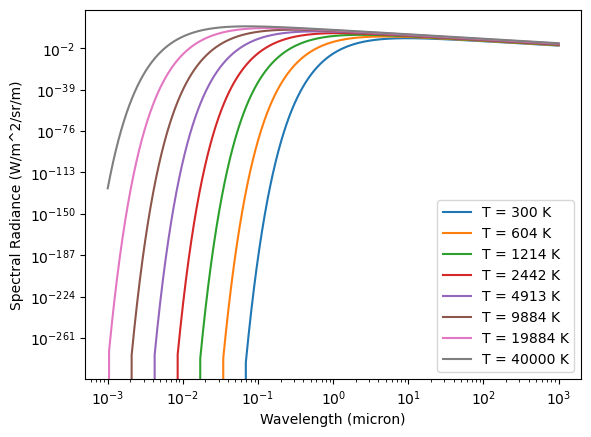

In [20]:
wavel = np.logspace(-3, 3, 1000) * u.micron
Tgrid = np.logspace(np.log10(300.), np.log10(40000.), 8) * u.K

B = [planck_function(wavel, T) for T in Tgrid]

for T in Tgrid:
    plt.plot(wavel, planck_function(wavel, T), label=f'T = {T.value:.0f} K')
plt.legend()
plt.loglog()
plt.xlabel('Wavelength (micron)')
plt.ylabel('Spectral Radiance (W/m^2/sr/m)')